<a href="https://colab.research.google.com/github/harshalrichu/-SOLUTION-TO-A-SYSTEM-OF-LINEAR-EQUATIONS/blob/main/Sobel_edge_detection_image_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install git+https://github.com/andreinechaev/nvcc4jupyter.git
%load_ext nvcc4jupyter

  Cloning https://github.com/andreinechaev/nvcc4jupyter.git to /tmp/pip-req-build-oc5gb377
  Running command git clone --filter=blob:none --quiet https://github.com/andreinechaev/nvcc4jupyter.git /tmp/pip-req-build-oc5gb377
  Resolved https://github.com/andreinechaev/nvcc4jupyter.git to commit 443a79479c90be4cc23adf7fe08db6e2a283e224
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nvcc4jupyter: filename=nvcc4jupyter-1.2.1-py3-none-any.whl size=11018 sha256=625e976658c98fd354f8800768c3a78a3d8cbb470e09e9c1d34f9ba15defe80f
  Stored in directory: /tmp/pip-ephem-wheel-cache-zok27510/wheels/7d/b9/66/459b9938664e6a93d1a85323ec52f7e51cd7265d253410a7d8
Successfully built nvcc4jupyter
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmp33sloden".


In [4]:
!nvcc --version


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [5]:
%load_ext nvcc4jupyter

The nvcc4jupyter extension is already loaded. To reload it, use:
  %reload_ext nvcc4jupyter


In [6]:
from pathlib import Path

file_path = Path('/absolute/path/to/images.jpeg')
if file_path.exists():
    print("File exists!")
else:
    print("File does not exist!")


File does not exist!


In [7]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: /content


In [8]:
from google.colab import files
uploaded = files.upload()

Saving thumb-1920-1379590.png to thumb-1920-1379590.png


In [19]:
from pathlib import Path

# Assuming the file is in the same directory as the notebook
file_path = Path('thumb-1920-1379590.png')
if file_path.exists():
    print("File exists!")
else:
    print("File does not exist!")


File exists!


In [10]:
pwd


'/content'

In [11]:
ls /content/images.jpeg

ls: cannot access '/content/images.jpeg': No such file or directory


In [20]:
#ls -l /content/images.jpeg
import cv2
image = cv2.imread('thumb-1920-1379590.png')
if image is None:
    print("Error: Image not found or unable to read the image.")
else:
    print("Image read successfully.")


Image read successfully.


In [23]:
%%writefile sobelEdgeDetectionFilter.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <cuda_runtime.h>
#include <opencv2/opencv.hpp>

using namespace cv;

__global__ void sobelFilter(unsigned char *srcImage, unsigned char *dstImage, unsigned int width, unsigned int height) {




int x = blockIdx.x * blockDim.x + threadIdx.x;
int y = blockIdx.y * blockDim.y + threadIdx.y;

float Kx[3][3] = {-1,0,1,-2,0,2,-1,0,1};
float Ky[3][3]= {1,2,1,0,0,0,-1,-2,-1};
if((x >=3/2))&&(x<(width - 3/2))&&(y>=3/2)&&(y<(height -3/2))
float Gx = 0;
for (int ky=-3/2;ky<=3/2;ky++){
  for(int kx =-3/2;kx<=3/2;kx++){
    folat fl=srcImage[((y+ky)*width+(x+kx))];
    Gx +=fl*Kx[ky + 3/2][kx +3/2];

  }
}
float Gx_abs=Gx<0? -Gx:Gx;
float Gy=0;
for (int ky=-3/2 ;ky<3/2 ;ky++){
  for(int kx=-3/2;kx<=3/2;kx++){
    float fl=scrImage[((y+ky) *width+(x+kx))];
    Gy+=f1*Ky[ky+3/2][kx+3/2];

  }

}
float Gy_abs=Gy <0?-Gy:Gy;
dstImage[(y*width+x)]=Gx_abs+Gy_abs;







}

void checkCudaErrors(cudaError_t r) {
    if (r != cudaSuccess) {
        fprintf(stderr, "CUDA Error: %s\n", cudaGetErrorString(r));
        exit(EXIT_FAILURE);
    }
}

int main() {
    // Read input image
    Mat image = imread("/content/images.jpeg", IMREAD_COLOR);

    if (image.empty()) {
        printf("Error: Image not found.\n");
        return -1;
    }

    int width = image.cols;
    int height = image.rows;
    size_t imageSize = width * height * sizeof(unsigned char);

    // Allocate host memory for output image
    unsigned char *h_outputImage = (unsigned char *)malloc(imageSize);
    if (h_outputImage == nullptr) {
        fprintf(stderr, "Failed to allocate host memory\n");
        return -1;
    }

    // Allocate device memory
    unsigned char *d_inputImage, *d_outputImage;
    checkCudaErrors(cudaMalloc(&d_inputImage, imageSize));
    checkCudaErrors(cudaMalloc(&d_outputImage, imageSize));
    checkCudaErrors(cudaMemcpy(d_inputImage, image.data, imageSize, cudaMemcpyHostToDevice));

    // Define CUDA events for timing
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    // Launch kernel
    dim3 blockSize(16, 16);
    dim3 gridSize(ceil(width / 16.0), ceil(height / 16.0));

    cudaEventRecord(start);
    sobelFilter<<<gridSize, blockSize>>>(d_inputImage, d_outputImage, width, height);
    cudaEventRecord(stop);

    // Synchronize events
    cudaEventSynchronize(stop);

    // Calculate elapsed time
    float milliseconds = 0;
    cudaEventElapsedTime(&milliseconds, start, stop);

    // Copy result back to host
    checkCudaErrors(cudaMemcpy(h_outputImage, d_outputImage, imageSize, cudaMemcpyDeviceToHost));

    // Write output image
    Mat outputImage(height, width, CV_8UC1, h_outputImage);
    imwrite("output_sobel.jpeg", outputImage);

    // Free memory
    free(h_outputImage);
    cudaFree(d_inputImage);
    cudaFree(d_outputImage);

    // Destroy CUDA events
    cudaEventDestroy(start);
    cudaEventDestroy(stop);

    // Print elapsed time
    printf("Total time taken: %f milliseconds\n", milliseconds);

    return 0;
}


Overwriting sobelEdgeDetectionFilter.cu


In [14]:
!nvcc -o sobelEdgeDetectionFilter sobelEdgeDetectionFilter.cu `pkg-config --cflags --libs opencv4`


Package opencv4 was not found in the pkg-config search path.
Perhaps you should add the directory containing `opencv4.pc'
to the PKG_CONFIG_PATH environment variable
Package 'opencv4', required by 'virtual:world', not found
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
sobelEdgeDetectionFilter.cu:5:10: fatal error: opencv2/opencv.hpp: No such file or directory
    5 | #include <opencv2/opencv.hpp>
      |          ^~~~~~~~~~~~~~~~~~~~
compilation terminated.


In [15]:
!./sobelEdgeDetectionFilter

/bin/bash: line 1: ./sobelEdgeDetectionFilter: No such file or directory


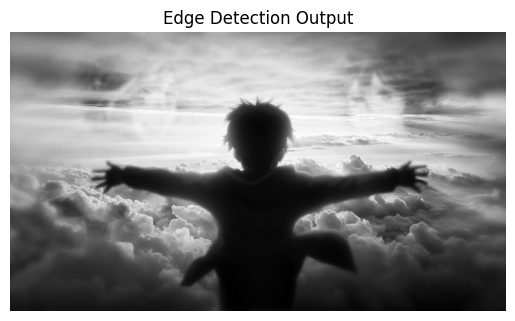

In [25]:
import cv2
from matplotlib import pyplot as plt

# Read and display the output image
output_image_path = 'thumb-1920-1379590.png'
output_image = cv2.imread(output_image_path, cv2.IMREAD_GRAYSCALE)  # Use IMREAD_GRAYSCALE if it's a single-channel image

# Display the image
plt.imshow(output_image, cmap='gray')
plt.title('Edge Detection Output')
plt.axis('off')  # Hide the axes
plt.show()
